# **ITC Hotels Project**

# **Starting the Project**

In [1]:
#Importing the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Importing the data file.
from google.colab import drive
drive.mount('/content/drive')
df_itc = pd.read_csv(r"/content/drive/MyDrive/ITC_Hotels.csv",sep= ',')

Mounted at /content/drive


# **Basic EDA**

1. Show the first 10 rows of the dataset.

In [2]:
print(df_itc.head(10))

  Booking_ID              Hotel_Name Hotel_Category       City          State  \
0  BK9835534            ITC Kakatiya         Luxury  Hyderabad      Telangana   
1  BK7803377        ITC Royal Bengal         Luxury    Kolkata    West Bengal   
2  BK3686278           ITC Grand Goa         Resort        Goa            Goa   
3  BK7514886  Fortune Select Trinity       Business  Bengaluru      Karnataka   
4  BK6312815             ITC Narmada       Business  Ahmedabad        Gujarat   
5  BK5563236               ITC Sonar       Business    Kolkata    West Bengal   
6  BK3946722           ITC Grand Goa         Resort        Goa            Goa   
7  BK5214751             ITC Maratha         Luxury     Mumbai    Maharashtra   
8  BK4623241            ITC Kakatiya         Luxury  Hyderabad      Telangana   
9  BK1623736              ITC Mughal         Resort       Agra  Uttar Pradesh   

  Country  Checkin_Date  Checkout_Date      Month Quarter  ...  Net_Revenue  \
0   India         44320      

2. How many rows and columns does the dataset have?

In [3]:
print('Number of records:',df_itc.shape[0])
print('Number of columns:',df_itc.shape[1])

Number of records: 300000
Number of columns: 28


3. Display all column names and their data types.

In [4]:
print('List of Column Names:',df_itc.columns.tolist())
print()
print(df_itc.dtypes)

List of Column Names: ['Booking_ID', 'Hotel_Name', 'Hotel_Category', 'City', 'State', 'Country', 'Checkin_Date', 'Checkout_Date', 'Month', 'Quarter', 'Year', 'Room_Type', 'Guests', 'Nights_Stayed', 'Room_Rate', 'Extra_Charges', 'Discount', 'Gross_Revenue', 'Net_Revenue', 'GST_Amount', 'Total_With_GST', 'Booking_Channel', 'Customer_Type', 'Payment_Mode', 'Occupancy_Status', 'Customer_Rating', 'Feedback_Status', 'Covid_Impact_Level']

Booking_ID             object
Hotel_Name             object
Hotel_Category         object
City                   object
State                  object
Country                object
Checkin_Date            int64
Checkout_Date           int64
Month                  object
Quarter                object
Year                    int64
Room_Type              object
Guests                  int64
Nights_Stayed           int64
Room_Rate               int64
Extra_Charges           int64
Discount                int64
Gross_Revenue           int64
Net_Revenue            

4. Show the statistical summary of all numeric columns.

In [5]:
print('Statistical summary of numeric columns')
print(df_itc.describe())
print()



Statistical summary of numeric columns
        Checkin_Date  Checkout_Date           Year         Guests  \
count  300000.000000  300000.000000  300000.000000  300000.000000   
mean    44468.697107   44471.698343    2021.245207       2.499310   
std       105.306123     105.311486       0.430210       1.117857   
min     44287.000000   44288.000000    2021.000000       1.000000   
25%     44378.000000   44380.000000    2021.000000       2.000000   
50%     44469.000000   44472.000000    2021.000000       2.000000   
75%     44560.000000   44563.000000    2021.000000       3.000000   
max     44651.000000   44656.000000    2022.000000       4.000000   

       Nights_Stayed      Room_Rate  Extra_Charges       Discount  \
count  300000.000000  300000.000000  300000.000000  300000.000000   
mean        3.001237   16230.221470    3500.705613    2500.406583   
std         1.414777    6788.146877    2018.906695    1443.983175   
min         1.000000    4500.000000       0.000000       0.0000

5. How many duplicate rows exist? Remove them and confirm the new shape.

In [6]:
print("Number of Duplicate Records:",df_itc.duplicated().sum())
print()
if df_itc.duplicated().sum() > 0:
  df_itc = df_itc.drop_duplicates
  print("Shape of Dataset:",df.shape())

Number of Duplicate Records: 0



6. Clean the data properly and format the data with the proper datatypes.

In [7]:
#Formatting the data with the proper datatypes
df_itc['Checkin_Date'] = pd.to_datetime(df_itc['Checkin_Date'])
df_itc['Checkout_Date'] = pd.to_datetime(df_itc['Checkout_Date'])
print('New datatypes',df_itc.dtypes)
print()

#Checking for null-values
print('Null values for each columns')
print(df_itc.isnull().sum())
print()

#Stripping the whitespaces in 'object' dtypes
for col in df_itc.select_dtypes(include='object').columns:
    df_itc[col] = df_itc[col].str.strip()


print('Data Cleaning: Completed')

New datatypes Booking_ID                    object
Hotel_Name                    object
Hotel_Category                object
City                          object
State                         object
Country                       object
Checkin_Date          datetime64[ns]
Checkout_Date         datetime64[ns]
Month                         object
Quarter                       object
Year                           int64
Room_Type                     object
Guests                         int64
Nights_Stayed                  int64
Room_Rate                      int64
Extra_Charges                  int64
Discount                       int64
Gross_Revenue                  int64
Net_Revenue                    int64
GST_Amount                   float64
Total_With_GST               float64
Booking_Channel               object
Customer_Type                 object
Payment_Mode                  object
Occupancy_Status              object
Customer_Rating              float64
Feedback_Status         

# **Feature Engineering**

1. Create a Revenue_Per_Night column: Net Revenue divided by Nights Stayed.

In [8]:
df_itc['Revenue_Per_Night'] = df_itc['Net_Revenue']/df_itc['Nights_Stayed']

2. Create a Discount_Pct column: Discount as a percentage of Gross Revenue.

In [9]:
df_itc['Discount_Pct'] = (df_itc['Discount']/df_itc['Gross_Revenue'])*100

3. Create a Revenue_Per_Guest column: Net Revenue divided by Guests.

In [10]:
df_itc['Revenue_Per_Guest'] = df_itc['Net_Revenue']/df_itc['Guests']

4. Create a High_Rating flag - 1 where Customer Rating >= 4.5, else 0.

In [11]:
df_itc["High_Rating"] = (df_itc["Customer_Rating"] >= 4.5).astype(np.int32)

5. Rename Covid_Impact_Level to Covid_Impact. Reorder so Booking_ID,Hotel_Name, City appear first.

In [12]:
df_itc.rename(columns={'Covid_Impact_Level':'Covid_Impact'},inplace = True)

df_itc[['Booking_ID','Hotel_Name','Hotel_Category','City','State','Country','Checkin_Date','Checkout_Date','Month','Quarter','Year','Room_Type','Guests','Nights_Stayed','Room_Rate','Extra_Charges','Discount','Gross_Revenue','Net_Revenue','GST_Amount','Total_With_GST','Booking_Channel','Customer_Type','Payment_Mode','Occupancy_Status','Customer_Rating','Feedback_Status','Covid_Impact']]
print('New Column Order')
print(df_itc.columns)

New Column Order
Index(['Booking_ID', 'Hotel_Name', 'Hotel_Category', 'City', 'State',
       'Country', 'Checkin_Date', 'Checkout_Date', 'Month', 'Quarter', 'Year',
       'Room_Type', 'Guests', 'Nights_Stayed', 'Room_Rate', 'Extra_Charges',
       'Discount', 'Gross_Revenue', 'Net_Revenue', 'GST_Amount',
       'Total_With_GST', 'Booking_Channel', 'Customer_Type', 'Payment_Mode',
       'Occupancy_Status', 'Customer_Rating', 'Feedback_Status',
       'Covid_Impact', 'Revenue_Per_Night', 'Discount_Pct',
       'Revenue_Per_Guest', 'High_Rating'],
      dtype='object')


# **Basic Business Queries**

1. List all bookings where Nights Stayed is greater than 3.

In [13]:
print('Total Bookings greater than 3:',df_itc[df_itc['Nights_Stayed'] > 3].shape[0])
print()
df1 = df_itc[df_itc['Nights_Stayed'] > 3]
df1

Total Bookings greater than 3: 119993



,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Checkin_Date,Checkout_Date,Month,Quarter,...,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact,Revenue_Per_Night,Discount_Pct,Revenue_Per_Guest,High_Rating
0,BK9835534,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044320,1970-01-01 00:00:00.000044324,May,Q2,...,Regular,UPI,Checked-Out,4.6,Positive,High,22290.00,3.783480,29720.000000,1
1,BK7803377,ITC Royal Bengal,Luxury,Kolkata,West Bengal,India,1970-01-01 00:00:00.000044352,1970-01-01 00:00:00.000044356,June,Q2,...,VIP,Credit Card,Checked-In,4.6,Positive,High,21707.50,4.627484,43415.000000,1
6,BK3946722,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044339,1970-01-01 00:00:00.000044344,May,Q2,...,Corporate,Debit Card,Checked-Out,4.8,Positive,High,21091.80,0.279892,52729.500000,1
8,BK4623241,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044615,1970-01-01 00:00:00.000044620,February,Q1,...,Regular,Net Banking,Checked-In,4.5,Positive,Low,22134.00,1.547905,36890.000000,1
10,BK4163929,ITC Gardenia,Luxury,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044620,1970-01-01 00:00:00.000044624,February,Q1,...,New Guest,Net Banking,Checked-In,3.4,Positive,Low,21510.25,4.355317,28680.333333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299986,BK9248678,ITC Windsor,Business,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044317,1970-01-01 00:00:00.000044322,May,Q2,...,Member,Credit Card,Checked-Out,4.6,Positive,High,21869.60,3.218155,27337.000000,1
299991,BK4168004,ITC Maurya,Luxury,New Delhi,Delhi,India,1970-01-01 00:00:00.000044613,1970-01-01 00:00:00.000044618,February,Q1,...,Corporate,Cash,Cancelled,3.9,Neutral,Low,25778.80,3.440784,32223.500000,0
299993,BK1654391,ITC Grand Chola,Luxury,Chennai,Tamil Nadu,India,1970-01-01 00:00:00.000044458,1970-01-01 00:00:00.000044463,September,Q3,...,Regular,Cash,Checked-In,3.5,Positive,Low,14103.60,3.654721,35259.000000,0
299997,BK9144694,ITC Narmada,Business,Ahmedabad,Gujarat,India,1970-01-01 00:00:00.000044584,1970-01-01 00:00:00.000044589,January,Q1,...,Regular,Credit Card,Checked-In,3.4,Positive,High,26776.60,1.495052,66941.500000,0


2. List all bookings made in the city of Goa.

In [14]:
print('Total Bookings Made in Goa:',df_itc[df_itc['City'] == 'Goa'].shape[0])
print()
df2 = df_itc[df_itc['City'] == 'Goa']
df2

Total Bookings Made in Goa: 20144



,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Checkin_Date,Checkout_Date,Month,Quarter,...,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact,Revenue_Per_Night,Discount_Pct,Revenue_Per_Guest,High_Rating
2,BK3686278,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044443,1970-01-01 00:00:00.000044445,September,Q3,...,Corporate,Cash,Checked-In,4.2,Positive,Low,14694.500000,11.454912,29389.000000,0
6,BK3946722,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044339,1970-01-01 00:00:00.000044344,May,Q2,...,Corporate,Debit Card,Checked-Out,4.8,Positive,High,21091.800000,0.279892,52729.500000,1
34,BK7940745,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044449,1970-01-01 00:00:00.000044453,September,Q3,...,Corporate,Debit Card,Checked-Out,4.5,Positive,Low,13132.500000,6.457013,17510.000000,1
78,BK7863891,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044608,1970-01-01 00:00:00.000044612,February,Q1,...,Member,Credit Card,Checked-In,4.6,Positive,Low,8549.500000,10.236758,8549.500000,1
95,BK7304177,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044502,1970-01-01 00:00:00.000044505,November,Q4,...,VIP,Cash,Checked-In,4.7,Neutral,Low,20082.000000,0.029869,15061.500000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299909,BK7104219,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044479,1970-01-01 00:00:00.000044483,October,Q4,...,Regular,Cash,Checked-In,3.5,Neutral,Low,26614.000000,2.629629,53228.000000,0
299926,BK2226110,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044458,1970-01-01 00:00:00.000044459,September,Q3,...,New Guest,Cash,Checked-Out,3.9,Positive,Low,28633.000000,5.871330,28633.000000,0
299979,BK2988796,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044596,1970-01-01 00:00:00.000044600,February,Q1,...,Corporate,Debit Card,Checked-In,4.6,Positive,Low,6364.250000,6.798711,8485.666667,1
299990,BK2473760,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044381,1970-01-01 00:00:00.000044384,July,Q3,...,New Guest,Cash,Checked-Out,5.0,Positive,Low,14881.333333,1.063735,11161.000000,1


3. Show bookings where Booking Channel is Walk-in and Nights Stayed > 2.

In [15]:
print('Total Bookings where Booking Channel is Walk-in and Nights Stayed > 2:',df_itc[(df_itc['Booking_Channel']=='Walk-in') & (df_itc['Nights_Stayed']>2)].shape[0])
print()
df3 = df_itc[(df_itc['Booking_Channel']=='Walk-in') & (df_itc['Nights_Stayed']>2)]
df3

Total Bookings where Booking Channel is Walk-in and Nights Stayed > 2: 29683



,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Checkin_Date,Checkout_Date,Month,Quarter,...,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact,Revenue_Per_Night,Discount_Pct,Revenue_Per_Guest,High_Rating
0,BK9835534,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044320,1970-01-01 00:00:00.000044324,May,Q2,...,Regular,UPI,Checked-Out,4.6,Positive,High,22290.000000,3.783480,29720.000000,1
8,BK4623241,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044615,1970-01-01 00:00:00.000044620,February,Q1,...,Regular,Net Banking,Checked-In,4.5,Positive,Low,22134.000000,1.547905,36890.000000,1
10,BK4163929,ITC Gardenia,Luxury,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044620,1970-01-01 00:00:00.000044624,February,Q1,...,New Guest,Net Banking,Checked-In,3.4,Positive,Low,21510.250000,4.355317,28680.333333,0
11,BK3327428,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044363,1970-01-01 00:00:00.000044366,June,Q2,...,Member,Cash,Checked-In,4.2,Negative,High,9140.333333,5.957199,9140.333333,0
36,BK5329282,ITC Kohenur,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044544,1970-01-01 00:00:00.000044548,December,Q4,...,Member,Debit Card,Checked-Out,3.8,Positive,Low,21712.250000,1.608719,21712.250000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299971,BK7465927,ITC Maurya,Luxury,New Delhi,Delhi,India,1970-01-01 00:00:00.000044492,1970-01-01 00:00:00.000044496,October,Q4,...,Member,Net Banking,Checked-Out,3.1,Positive,Low,10546.000000,6.724157,10546.000000,0
299972,BK9863222,ITC Gardenia,Luxury,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044581,1970-01-01 00:00:00.000044586,January,Q1,...,Regular,Credit Card,Checked-In,3.6,Positive,High,15708.000000,2.280617,19635.000000,0
299982,BK5783774,ITC Sonar,Business,Kolkata,West Bengal,India,1970-01-01 00:00:00.000044555,1970-01-01 00:00:00.000044558,December,Q4,...,VIP,Credit Card,Checked-Out,4.8,Positive,Low,17093.000000,3.813400,51279.000000,1
299991,BK4168004,ITC Maurya,Luxury,New Delhi,Delhi,India,1970-01-01 00:00:00.000044613,1970-01-01 00:00:00.000044618,February,Q1,...,Corporate,Cash,Cancelled,3.9,Neutral,Low,25778.800000,3.440784,32223.500000,0


4. Show bookings where Customer Rating is 5.0 or Net Revenue is above 100000.

In [16]:
print('Total Bookings where Customer rating is 5.0 or revenue >100000:',df_itc[(df_itc['Customer_Rating'] == 5.0) | (df_itc['Net_Revenue'] > 100000)].shape[0])
print()
df4 = df_itc[(df_itc['Customer_Rating'] == 5.0) | (df_itc['Net_Revenue'] > 100000)]
df4

Total Bookings where Customer rating is 5.0 or revenue >100000: 35865



,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Checkin_Date,Checkout_Date,Month,Quarter,...,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact,Revenue_Per_Night,Discount_Pct,Revenue_Per_Guest,High_Rating
6,BK3946722,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044339,1970-01-01 00:00:00.000044344,May,Q2,...,Corporate,Debit Card,Checked-Out,4.8,Positive,High,21091.800000,0.279892,52729.5,1
8,BK4623241,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044615,1970-01-01 00:00:00.000044620,February,Q1,...,Regular,Net Banking,Checked-In,4.5,Positive,Low,22134.000000,1.547905,36890.0,1
43,BK7172862,ITC Windsor,Business,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044389,1970-01-01 00:00:00.000044393,July,Q3,...,Member,Net Banking,Cancelled,3.7,Negative,Low,27614.000000,0.264562,27614.0,0
46,BK8487740,Welcomhotel Dwarka,Business,New Delhi,Delhi,India,1970-01-01 00:00:00.000044325,1970-01-01 00:00:00.000044326,May,Q2,...,Member,Net Banking,Checked-In,5.0,Positive,High,7978.000000,33.918661,7978.0,1
64,BK2384478,ITC Windsor,Business,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044548,1970-01-01 00:00:00.000044553,December,Q4,...,Corporate,Credit Card,Checked-In,5.0,Negative,Low,13702.400000,5.351864,68512.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299952,BK1742029,ITC Gardenia,Luxury,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044346,1970-01-01 00:00:00.000044351,May,Q2,...,Regular,Credit Card,Cancelled,4.2,Neutral,High,26011.600000,1.864498,65029.0,0
299986,BK9248678,ITC Windsor,Business,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044317,1970-01-01 00:00:00.000044322,May,Q2,...,Member,Credit Card,Checked-Out,4.6,Positive,High,21869.600000,3.218155,27337.0,1
299990,BK2473760,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044381,1970-01-01 00:00:00.000044384,July,Q3,...,New Guest,Cash,Checked-Out,5.0,Positive,Low,14881.333333,1.063735,11161.0,1
299991,BK4168004,ITC Maurya,Luxury,New Delhi,Delhi,India,1970-01-01 00:00:00.000044613,1970-01-01 00:00:00.000044618,February,Q1,...,Corporate,Cash,Cancelled,3.9,Neutral,Low,25778.800000,3.440784,32223.5,0


5. Use query() to find all Luxury hotel bookings with Customer Rating above 4.0.

In [17]:
print('Total Luxury and above 4.0 Bookings:',df_itc.query("(Hotel_Category == 'Luxury' ) & (Customer_Rating > 4.0)").shape[0] )
print()
df5 = df_itc.query("(Hotel_Category == 'Luxury' ) & (Customer_Rating > 4.0)")
df5

Total Luxury and above 4.0 Bookings: 66772



,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Checkin_Date,Checkout_Date,Month,Quarter,...,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact,Revenue_Per_Night,Discount_Pct,Revenue_Per_Guest,High_Rating
0,BK9835534,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044320,1970-01-01 00:00:00.000044324,May,Q2,...,Regular,UPI,Checked-Out,4.6,Positive,High,22290.000000,3.783480,29720.000000,1
1,BK7803377,ITC Royal Bengal,Luxury,Kolkata,West Bengal,India,1970-01-01 00:00:00.000044352,1970-01-01 00:00:00.000044356,June,Q2,...,VIP,Credit Card,Checked-In,4.6,Positive,High,21707.500000,4.627484,43415.000000,1
7,BK5214751,ITC Maratha,Luxury,Mumbai,Maharashtra,India,1970-01-01 00:00:00.000044592,1970-01-01 00:00:00.000044593,January,Q1,...,Regular,Debit Card,Checked-Out,4.3,Positive,High,15926.000000,11.693928,7963.000000,0
8,BK4623241,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044615,1970-01-01 00:00:00.000044620,February,Q1,...,Regular,Net Banking,Checked-In,4.5,Positive,Low,22134.000000,1.547905,36890.000000,1
11,BK3327428,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044363,1970-01-01 00:00:00.000044366,June,Q2,...,Member,Cash,Checked-In,4.2,Negative,High,9140.333333,5.957199,9140.333333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299973,BK4946025,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044481,1970-01-01 00:00:00.000044484,October,Q4,...,New Guest,Net Banking,Checked-In,4.4,Negative,Low,8529.000000,9.294906,8529.000000,0
299976,BK5468478,ITC Maratha,Luxury,Mumbai,Maharashtra,India,1970-01-01 00:00:00.000044427,1970-01-01 00:00:00.000044429,August,Q3,...,VIP,Credit Card,Checked-In,4.8,Positive,Low,26827.000000,2.242871,13413.500000,1
299980,BK1407147,ITC Gardenia,Luxury,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044305,1970-01-01 00:00:00.000044310,April,Q2,...,New Guest,Cash,Checked-In,4.1,Positive,High,17897.800000,3.815604,89489.000000,0
299984,BK9747747,ITC Royal Bengal,Luxury,Kolkata,West Bengal,India,1970-01-01 00:00:00.000044598,1970-01-01 00:00:00.000044602,February,Q1,...,VIP,Cash,Cancelled,4.2,Positive,Low,9748.250000,6.388342,19496.500000,0


6. Show all Presidential Suite bookings sorted by Net Revenue, highest first.

In [18]:
print('Total President Suite Bookings:',df_itc[df_itc['Room_Type']=='Presidential Suite'].shape[0])
print()
df6 = df_itc[df_itc['Room_Type']=='Presidential Suite']
df6.sort_values(by='Net_Revenue',ascending=False)

Total President Suite Bookings: 60022



,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Checkin_Date,Checkout_Date,Month,Quarter,...,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact,Revenue_Per_Night,Discount_Pct,Revenue_Per_Guest,High_Rating
216470,BK1380062,ITC Sonar,Business,Kolkata,West Bengal,India,1970-01-01 00:00:00.000044607,1970-01-01 00:00:00.000044612,February,Q1,...,Regular,UPI,Cancelled,3.5,Positive,Low,29150.4,0.448063,72876.000000,0
297573,BK9226437,ITC Windsor,Business,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044579,1970-01-01 00:00:00.000044584,January,Q1,...,Regular,Net Banking,Checked-In,4.8,Negative,High,29112.0,0.762890,145560.000000,1
132609,BK1769799,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044386,1970-01-01 00:00:00.000044391,July,Q3,...,Corporate,UPI,Checked-Out,4.1,Positive,Low,29104.8,0.089253,48508.000000,0
2773,BK5532504,ITC Grand Goa,Resort,Goa,Goa,India,1970-01-01 00:00:00.000044537,1970-01-01 00:00:00.000044542,December,Q4,...,New Guest,Cash,Checked-Out,3.5,Neutral,Low,29098.8,0.272121,145494.000000,0
209870,BK1910528,ITC Grand Chola,Luxury,Chennai,Tamil Nadu,India,1970-01-01 00:00:00.000044354,1970-01-01 00:00:00.000044359,June,Q2,...,Regular,Net Banking,Checked-In,3.4,Positive,High,29061.4,0.381180,145307.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185991,BK5705068,ITC Sonar,Business,Kolkata,West Bengal,India,1970-01-01 00:00:00.000044567,1970-01-01 00:00:00.000044568,January,Q1,...,Member,UPI,Checked-In,4.6,Positive,High,762.0,86.598663,762.000000,1
66621,BK2222568,Fortune Select Trinity,Business,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044595,1970-01-01 00:00:00.000044596,February,Q1,...,New Guest,Net Banking,Checked-In,4.3,Negative,Low,751.0,86.879804,250.333333,0
123508,BK2165425,ITC Narmada,Business,Ahmedabad,Gujarat,India,1970-01-01 00:00:00.000044516,1970-01-01 00:00:00.000044517,November,Q4,...,New Guest,Net Banking,Checked-Out,3.7,Positive,Low,716.0,86.233417,358.000000,0
13708,BK9089616,ITC Sonar,Business,Kolkata,West Bengal,India,1970-01-01 00:00:00.000044502,1970-01-01 00:00:00.000044503,November,Q4,...,VIP,Credit Card,Checked-Out,4.1,Negative,Low,251.0,95.057109,125.500000,0


7. What is the total Net Revenue across all bookings?

In [19]:
print('Total Net Revenue:',df_itc['Net_Revenue'].sum())

Total Net Revenue: 14914832342


8. What is the maximum and minimum Customer Rating?

In [20]:
df_itc['Customer_Rating'].agg(['min','max'])

,Customer_Rating
min,3.0
max,5.0


9. Show all bookings with zero discount applied.

In [21]:
print('Total Bookings with 0 discounts:',df_itc[df_itc['Discount'] == 0].shape[0])
print()
df9 = df_itc[df_itc['Discount'] == 0]
df9

Total Bookings with 0 discounts: 68



,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Checkin_Date,Checkout_Date,Month,Quarter,...,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact,Revenue_Per_Night,Discount_Pct,Revenue_Per_Guest,High_Rating
7550,BK6294625,Fortune Select Trinity,Business,Bengaluru,Karnataka,India,1970-01-01 00:00:00.000044622,1970-01-01 00:00:00.000044627,March,Q1,...,New Guest,Cash,Checked-In,3.7,Negative,Low,6733.000000,0.0,11221.666667,0
9008,BK4830133,Welcomhotel Dwarka,Business,New Delhi,Delhi,India,1970-01-01 00:00:00.000044287,1970-01-01 00:00:00.000044291,April,Q2,...,New Guest,UPI,Checked-In,3.4,Positive,High,17665.250000,0.0,70661.000000,0
13285,BK3351156,ITC Maurya,Luxury,New Delhi,Delhi,India,1970-01-01 00:00:00.000044469,1970-01-01 00:00:00.000044472,September,Q3,...,New Guest,Cash,No Show,4.3,Positive,Low,27238.333333,0.0,27238.333333,0
14158,BK8712734,Welcomhotel Dwarka,Business,New Delhi,Delhi,India,1970-01-01 00:00:00.000044573,1970-01-01 00:00:00.000044578,January,Q1,...,Member,Credit Card,No Show,4.8,Positive,High,15653.000000,0.0,39132.500000,1
19019,BK4355601,ITC Sonar,Business,Kolkata,West Bengal,India,1970-01-01 00:00:00.000044322,1970-01-01 00:00:00.000044325,May,Q2,...,New Guest,Debit Card,Checked-Out,3.0,Positive,High,7207.666667,0.0,5405.750000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285287,BK5985810,ITC Maratha,Luxury,Mumbai,Maharashtra,India,1970-01-01 00:00:00.000044310,1970-01-01 00:00:00.000044314,April,Q2,...,Regular,Cash,No Show,3.6,Positive,High,12706.000000,0.0,16941.333333,0
288673,BK1890707,ITC Rajputana,Business,Jaipur,Rajasthan,India,1970-01-01 00:00:00.000044629,1970-01-01 00:00:00.000044630,March,Q1,...,Regular,Credit Card,Checked-Out,4.8,Positive,Low,19290.000000,0.0,6430.000000,1
292020,BK3423471,ITC Kohenur,Luxury,Hyderabad,Telangana,India,1970-01-01 00:00:00.000044444,1970-01-01 00:00:00.000044448,September,Q3,...,New Guest,Cash,Checked-In,3.0,Positive,Low,6453.250000,0.0,25813.000000,0
296816,BK6802326,ITC Maurya,Luxury,New Delhi,Delhi,India,1970-01-01 00:00:00.000044388,1970-01-01 00:00:00.000044391,July,Q3,...,VIP,Cash,Cancelled,4.6,Positive,Low,8629.000000,0.0,12943.500000,1


# **NumPy Analysis**

1. Descriptive statistics on Net Revenue using NumPy.

In [22]:
df_itc['Net_Revenue'].agg([
    'min','max','mean','median','std','var','sum','count'
])

,Net_Revenue
min,-2.110000e+02
max,1.457520e+05
mean,4.971611e+04
median,4.247750e+04
std,3.225536e+04
var,1.040408e+09
sum,1.491483e+10
count,3.000000e+05


2. Use np.unique() on Nights Stayed, Year, and Quarter.

In [23]:
a =np.unique(df_itc['Nights_Stayed'])
print('Unique Nights Stayed:',a)
print()
b =np.unique(df_itc['Year'])
print('Unique Years:',b)
print()
c =np.unique(df_itc['Quarter'])
print('Unique Quarters:',c)

Unique Nights Stayed: [1 2 3 4 5]

Unique Years: [2021 2022]

Unique Quarters: ['Q1' 'Q2' 'Q3' 'Q4']


3. Boolean mask - count bookings where Discount > 3000. Show as percentage.

In [24]:
boolean_mask = df_itc[df_itc['Discount'] > 3000].shape[0]/df_itc.shape[0]*100
print('Bookings percentage where Discount > 3000:',boolean_mask,'%')

Bookings percentage where Discount > 3000: 39.986 %


4. 2D matrix from Net Revenue and GST Amount. np.sum on axis=0 and axis=1.

In [25]:
arr = np.array(df_itc[['Net_Revenue','GST_Amount']])
print('Total Net Revenue and GST respectively:',np.sum(arr,axis=0))
print()
print('Sum of Revenue and GST:',np.sum(arr,axis=1))

Total Net Revenue and GST respectively: [1.49148323e+10 1.78977988e+09]

Sum of Revenue and GST: [ 99859.2   97249.6   32915.68 ... 149948.96  43613.92  38664.64]


5. Quarterly Net Revenue - np.diff() and np.cumsum().

In [26]:
print('Quarterly Net Revenue Difference:',np.diff(df_itc.groupby('Quarter')['Net_Revenue'].sum()))
print()
print('Quarterly Net Revenue Cumulative Sum:',np.cumsum(df_itc.groupby('Quarter')['Net_Revenue'].sum()))

Quarterly Net Revenue Difference: [85345260  6403281 22444564]

Quarterly Net Revenue Cumulative Sum: Quarter
Q1     3655886359
Q2     7397117978
Q3    11144752878
Q4    14914832342
Name: Net_Revenue, dtype: int64


6. Compare np.mean() and np.median(). State if distribution is skewed.

Yes, the distribution is positively skewed as mean(49,716) is greater than the median(42,477).

In [27]:
print('Mean:',np.mean(df_itc['Net_Revenue']))
print('Median:',np.median(df_itc['Net_Revenue']))

Mean: 49716.10780666667
Median: 42477.5


# **Advanced Pandas Queries**

1. Total Net Revenue per Hotel Category. Sort highest to lowest.

In [28]:
total_net_revenue = df_itc.groupby('Hotel_Category')['Net_Revenue'].sum()
total_net_revenue.sort_values(ascending=False)

,Net_Revenue
Hotel_Category,
Luxury,6966150435
Business,5945197650
Resort,2003484257


2. Average Customer Rating per Room Type. Sort best to worst.

In [29]:
avg_cust_rating = df_itc.groupby('Room_Type')['Customer_Rating'].mean()
avg_cust_rating.sort_values(ascending=False)

,Customer_Rating
Room_Type,
Luxury Suite,4.004611
Executive,4.002105
Club Room,3.999627
Presidential Suite,3.998889
Deluxe,3.998424


3. Top 5 cities by total Net Revenue.

In [30]:
top_5_cities = df_itc.groupby('City')['Net_Revenue'].sum().rank(method='dense')
top_5_cities.sort_values(ascending=False).head(5)

,Net_Revenue
City,
Bengaluru,10.0
New Delhi,9.0
Hyderabad,8.0
Kolkata,7.0
Agra,6.0


4. Average Net Revenue per booking for each Booking Channel. Sort descending.

In [31]:
avg_revenue_per_booking = df_itc.groupby('Booking_Channel')['Net_Revenue'].mean()
avg_revenue_per_booking.sort_values(ascending=False)

,Net_Revenue
Booking_Channel,
Website,49908.150040
MakeMyTrip,49811.887338
Corporate,49807.501436
Goibibo,49634.251441
Booking.com,49568.568390
Walk-in,49565.198264


5. Total Gross Revenue per Month.

In [32]:
total_gross_revenue = df_itc.groupby('Month')['Gross_Revenue'].sum()
total_gross_revenue.sort_values()

,Gross_Revenue
Month,
February,1179301678
November,1280521368
September,1283027675
June,1287885003
April,1292616588
March,1326467336
July,1326558408
August,1326833226
December,1331552266


6. Multi-metric aggregation for Hotel Category in one agg() call.

In [33]:
multi_metric_agg = df_itc.groupby("Hotel_Category")["Net_Revenue"].agg(
    Total_Revenue   = "sum",
    Avg_Revenue     = "mean",
    Highest_Booking = "max",
    Lowest_Booking  = "min",
    Booking_Count   = "count"
)
multi_metric_agg.sort_values(by="Total_Revenue",ascending=False)

,Total_Revenue,Avg_Revenue,Highest_Booking,Lowest_Booking,Booking_Count
Hotel_Category,,,,,
Luxury,6966150435,49777.417254,145567,71,139946
Business,5945197650,49696.544763,145752,31,119630
Resort,2003484257,49561.751855,145494,-211,40424


7. Average Customer Rating and booking count per Hotel Name.

In [34]:
avg_cust_rating = df_itc.groupby('Hotel_Name')['Customer_Rating'].mean().sort_values(ascending=False)
print('Average Customer Rating per Hotel')
print(avg_cust_rating.sort_values(ascending=False))
print()

avg_booking_count = df_itc.groupby('Hotel_Name')['Booking_ID'].count().sort_values(ascending=False)
print('Average Booking Count per Hotel')
avg_booking_count.sort_values(ascending=False)

Average Customer Rating per Hotel
Hotel_Name
ITC Maurya                4.008854
ITC Royal Bengal          4.008070
ITC Kakatiya              4.006704
Fortune Select Trinity    4.003914
ITC Sonar                 4.003780
ITC Mughal                4.002081
ITC Narmada               4.001666
ITC Gardenia              4.001608
ITC Windsor               3.999024
ITC Grand Chola           3.998997
ITC Rajputana             3.997755
ITC Maratha               3.997324
ITC Kohenur               3.995327
Welcomhotel Dwarka        3.993648
ITC Grand Goa             3.992310
Name: Customer_Rating, dtype: float64

Average Booking Count per Hotel


,Booking_ID
Hotel_Name,
ITC Mughal,20280
ITC Grand Goa,20144
ITC Maratha,20139
ITC Kakatiya,20092
ITC Rajputana,20087
ITC Windsor,20085
ITC Grand Chola,20049
ITC Maurya,20047
Welcomhotel Dwarka,19977


8. Total Net Revenue grouped by Year and Quarter.

In [35]:
total_net_revenue_grouped = df_itc.groupby(['Year','Quarter'])['Net_Revenue'].sum()
print('Total Net Revenue for FY21')
total_net_revenue_grouped

Total Net Revenue for FY21


Year  Quarter
2021  Q2         3741231619
      Q3         3747634900
      Q4         3770079464
2022  Q1         3655886359
Name: Net_Revenue, dtype: int64

9. Keep only Hotel Categories whose average Net Revenue is above the overall average.

In [36]:
above_avg = df_itc.groupby('Hotel_Category').filter(lambda x :x['Net_Revenue'].mean() > df_itc['Net_Revenue'].mean())
above_avg.groupby('Hotel_Category')['Net_Revenue'].mean().sort_values(ascending=False)

,Net_Revenue
Hotel_Category,
Luxury,49777.417254


10. Average Discount_Pct per Customer Type. Sort descending.

In [37]:
avg_discount = df_itc.groupby('Customer_Type')['Discount'].mean()
avg_discount.sort_values(ascending=False)

,Discount
Customer_Type,
VIP,2508.992990
Member,2503.806324
New Guest,2500.661957
Regular,2497.856604
Corporate,2490.748220


11. Total revenue, avg revenue, and booking count per Payment Mode.

In [38]:
total_revenue_per_payment_mode = df_itc.groupby('Payment_Mode')['Net_Revenue'].agg(
    Total_Revenue   = "sum",
    Avg_Revenue     = "mean",
    Booking_Count   = "count"
)
total_revenue_per_payment_mode.sort_values(by="Total_Revenue",ascending=False)

,Total_Revenue,Avg_Revenue,Booking_Count
Payment_Mode,,,
Cash,2996381438,49847.472809,60111
Net Banking,2987806180,49707.296533,60108
Credit Card,2980109675,49863.794445,59765
Debit Card,2978379565,49686.861936,59943
UPI,2972155484,49475.729263,60073


12. Rank all cities by average Net Revenue using rank(method='dense').

In [39]:
city_rank = df_itc.groupby('City')['Net_Revenue'].mean().rank(method='dense')
city_rank.sort_values(ascending=False)

,Net_Revenue
City,
Agra,10.0
Mumbai,9.0
New Delhi,8.0
Hyderabad,7.0
Kolkata,6.0
Ahmedabad,5.0
Bengaluru,4.0
Chennai,3.0
Jaipur,2.0


13. All Negative feedback bookings. Count per Hotel Name.

In [40]:
neg_feedback = df_itc[df_itc['Feedback_Status']=='Negative']
neg_feedback.groupby('Hotel_Name')['Booking_ID'].count().sort_values(ascending=False)

,Booking_ID
Hotel_Name,
ITC Windsor,2031
ITC Kakatiya,2026
ITC Maratha,2025
ITC Grand Chola,2025
ITC Grand Goa,1995
ITC Kohenur,1992
ITC Gardenia,1985
ITC Rajputana,1981
ITC Narmada,1974


# **Business Insights**

1. Which hotel category should be prioritised for expansion?

Luxury beats all the other categories on total revenue, average revenue and total number of bookings. Capital expenditure on Luxury hotel category yields the best ROI.

In [41]:
expansion_priority = df_itc.groupby('Hotel_Category')['Net_Revenue'].agg(
    Total_Revenue = 'sum',
    Avg_Revenue = 'mean',
    Count_of_Bookings = 'count'
)
expansion_priority.sort_values(by =['Total_Revenue','Avg_Revenue','Count_of_Bookings'],ascending=[False,False,False])



,Total_Revenue,Avg_Revenue,Count_of_Bookings
Hotel_Category,,,
Luxury,6966150435,49777.417254,139946
Business,5945197650,49696.544763,119630
Resort,2003484257,49561.751855,40424


2. Which booking channels should get more marketing investment?

Website and Corporate channels should get more marketing investment as they have highest average revenue and are direct channels with untapped volumes and zero commission leakage.

In [42]:
marketing_investment = df_itc.groupby('Booking_Channel')['Net_Revenue'].agg(
    Total_Revenue = 'sum',
    Avg_Revenue = 'mean',
    Count_of_Bookings = 'count'
)
marketing_investment.sort_values(by =['Total_Revenue','Avg_Revenue','Count_of_Bookings'],ascending=[False,False,False])

,Total_Revenue,Avg_Revenue,Count_of_Bookings
Booking_Channel,,,
MakeMyTrip,2498514457,49811.887338,50159
Corporate,2496650817,49807.501436,50126
Website,2493411176,49908.150040,49960
Booking.com,2484227942,49568.568390,50117
Goibibo,2480322813,49634.251441,49972
Walk-in,2461705137,49565.198264,49666


3. How much does COVID impact level affect per-booking revenue?

High covid impact period crushed revenue via government set occupancy caps and frozen corporate travels.

In [43]:
covid_impact = df_itc.groupby('Covid_Impact')['Net_Revenue'].agg(
    Total_Revenue = 'sum',
    Avg_Revenue = 'mean',
    Count_of_Bookings = 'count'
)
covid_impact

,Total_Revenue,Avg_Revenue,Count_of_Bookings
Covid_Impact,,,
High,5011748280,49819.066591,100599
Low,9903084062,49664.164483,199401


4. Use groupby filter() to isolate high-performing hotel categories.

In [44]:
high_performing_hotels = df_itc.groupby('Hotel_Category').filter(lambda x: x['Net_Revenue'].mean() > df_itc['Net_Revenue'].mean())
hotel_performance_metrics = high_performing_hotels.groupby('Hotel_Name')['Net_Revenue'].agg(
    Total_Revenue = 'sum',
    Avg_Revenue = 'mean',
    Count_of_Bookings = 'count'
)
hotel_performance_metrics.sort_values(by =['Total_Revenue','Avg_Revenue','Count_of_Bookings'],ascending=[False,False,False])

,Total_Revenue,Avg_Revenue,Count_of_Bookings
Hotel_Name,,,
ITC Maratha,1006409657,49973.169323,20139
ITC Kakatiya,1004671534,50003.560323,20092
ITC Maurya,995820282,49674.279543,20047
ITC Grand Chola,993758675,49566.495835,20049
ITC Royal Bengal,990544210,49713.636637,19925
ITC Kohenur,987995059,49747.988872,19860
ITC Gardenia,986951018,49760.563578,19834


5. Does giving a higher discount lead to a better rating?

Discount and Customer Rating has near zero correlation.
Discount does not buy satisfaction. Service quality, room cleanliness, and staff behaviour drive ratings and not price cuts.

In [45]:
corr_dis_rating = df_itc["Discount"].corr(df_itc["Customer_Rating"])
print('Corelation between discount and customer rating:',round(corr_dis_rating,3))

Corelation between discount and customer rating: 0.002


6. What does std() and var() on Net Revenue tell about booking value?

A high standard deviation signals extreme booking value differences. ITC Hotels serves both modest 1-night stays and multi-night presidential bookings which created a high standard deviation.

In [46]:
print('Standard Variance of Net Revenue:',round(df_itc['Net_Revenue'].std(),2))
print()
print('Variance of Net Revenue:',round(df_itc['Net_Revenue'].var(),2))

Standard Variance of Net Revenue: 32255.36

Variance of Net Revenue: 1040408175.57


7. Compare avg Net Revenue - VIP vs Corporate customers.

Corporate customer has higher average net revenue compared to vip customers due to their higher volumes and average room rates

In [47]:
vip_revenue = df_itc[df_itc['Customer_Type'] == 'VIP']['Net_Revenue'].mean()
corporate_revenue = df_itc[df_itc['Customer_Type'] == 'Corporate']['Net_Revenue'].mean()
print('Average Net Revenue for VIP:',round(vip_revenue,2))
print('Average Net Revenue for Corporate:',round(corporate_revenue,2))
print()
diff_revenue = corporate_revenue - vip_revenue
print('Difference in Average Net Revenue between corporate and vip customers:',round(diff_revenue,2))

#check = df_itc.groupby('Customer_Type')['Room_Rate'].mean()
#check

Average Net Revenue for VIP: 49530.87
Average Net Revenue for Corporate: 49875.62

Difference in Average Net Revenue between corporate and vip customers: 344.75


8. Top 10 bookings by Net Revenue - which room types dominate?

Presidential Suite dominates the hotel's ultra-premium inventory, concentrating at 70% of top-10 highest revenue bookings. It confirms that premium inventory is not oversupplied but rather there is a strong-willingness to pay for the top-end products.

In [48]:
top_10_bookings = df_itc.sort_values(by='Net_Revenue',ascending=False).head(10)
print(top_10_bookings[['Booking_ID','Hotel_Name','Hotel_Category','Room_Type','City','Net_Revenue','Booking_Channel','Customer_Type','Customer_Rating']])

print()
top_rooms = top_10_bookings.groupby('Room_Type')['Net_Revenue'].count()
top_rooms.sort_values(ascending=False)

       Booking_ID       Hotel_Name Hotel_Category           Room_Type  \
216470  BK1380062        ITC Sonar       Business  Presidential Suite   
111582  BK6765618     ITC Gardenia         Luxury           Executive   
297573  BK9226437      ITC Windsor       Business  Presidential Suite   
132609  BK1769799     ITC Kakatiya         Luxury  Presidential Suite   
2773    BK5532504    ITC Grand Goa         Resort  Presidential Suite   
209870  BK1910528  ITC Grand Chola         Luxury  Presidential Suite   
216779  BK6598529      ITC Kohenur         Luxury  Presidential Suite   
187813  BK8059629      ITC Windsor       Business  Presidential Suite   
298834  BK1553946        ITC Sonar       Business        Luxury Suite   
174754  BK3460055    ITC Rajputana       Business           Executive   

             City  Net_Revenue Booking_Channel Customer_Type  Customer_Rating  
216470    Kolkata       145752       Corporate       Regular              3.5  
111582  Bengaluru       145567      

,Net_Revenue
Room_Type,
Presidential Suite,7
Executive,2
Luxury Suite,1


9. Payment Mode - which mode should be prioritised?

Credit Card should be priotised while buiding a payment infrastructure.
credit card are staple for corporate and high-quality custumer segment bringing higher highest average net revenue.Therefore ITC should incentivise high-value payment modes through their own co-branded credit card partnerships offering loyalty points, room upgrades, and complimentary services to credit card users.

In [49]:
payment_mode_priority = df_itc.groupby('Payment_Mode')['Net_Revenue'].agg(
    Total_Revenue = 'sum',
    Avg_Revenue = 'mean',
    Count_of_Bookings = 'count'
)
payment_mode_priority.sort_values(by =['Avg_Revenue','Count_of_Bookings'],ascending=[False,False])

,Total_Revenue,Avg_Revenue,Count_of_Bookings
Payment_Mode,,,
Credit Card,2980109675,49863.794445,59765
Cash,2996381438,49847.472809,60111
Net Banking,2987806180,49707.296533,60108
Debit Card,2978379565,49686.861936,59943
UPI,2972155484,49475.729263,60073


# **Visualizations**

1. Bar chart - total Net Revenue by Hotel Category.

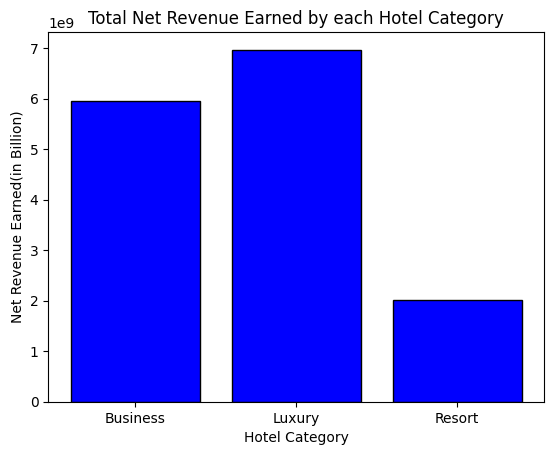

In [50]:
plt.bar(total_net_revenue.index,total_net_revenue.values,color='blue',edgecolor='black')
plt.xlabel('Hotel Category')
plt.ylabel('Net Revenue Earned(in Billion)')
plt.title('Total Net Revenue Earned by each Hotel Category')
plt.savefig('Net_Revenue_by_Category.png')
plt.show()

2. Line chart - total Net Revenue by Month.

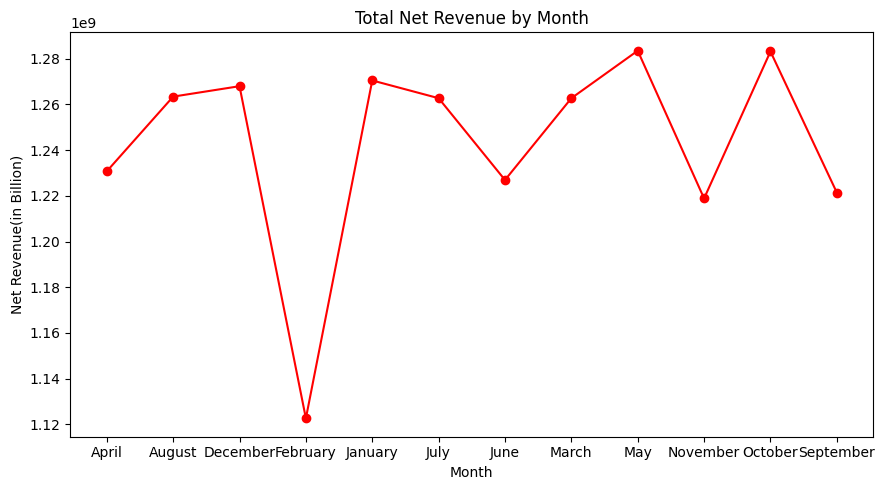

In [51]:
plt.figure(figsize=(9,5))
net_revenue_month= df_itc.groupby('Month')['Net_Revenue'].sum()
plt.plot(net_revenue_month.index,net_revenue_month.values, color='red',marker='o')

plt.xlabel('Month')
plt.ylabel('Net Revenue(in Billion)')
plt.title('Total Net Revenue by Month')

plt.tight_layout()
plt.savefig('Net_Revenue_by_Month.png')
plt.show()

3. Histogram - Customer Rating with custom bins.

<function matplotlib.pyplot.show(close=None, block=None)>

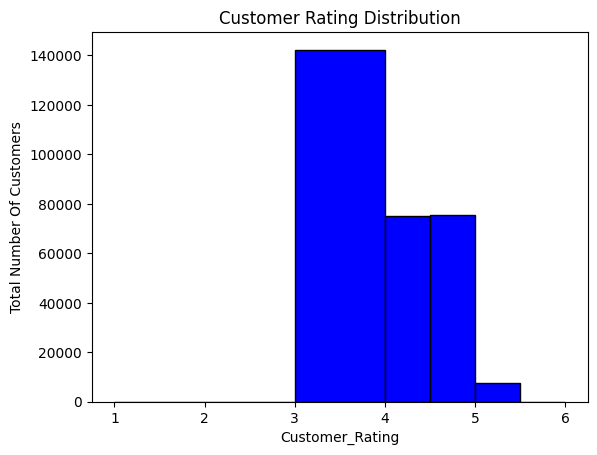

In [52]:
custom_bin = [1,2,3,4,4.5,5.0,5.5,6]
plt.hist(df_itc['Customer_Rating'],custom_bin,color='blue', edgecolor='black')
plt.xlabel('Customer_Rating')
plt.ylabel('Total Number Of Customers')
plt.title('Customer Rating Distribution')

plt.savefig('Customer_Rating_Distribution.png')
plt.show

4. Two line series - Net Revenue vs Gross Revenue across months.

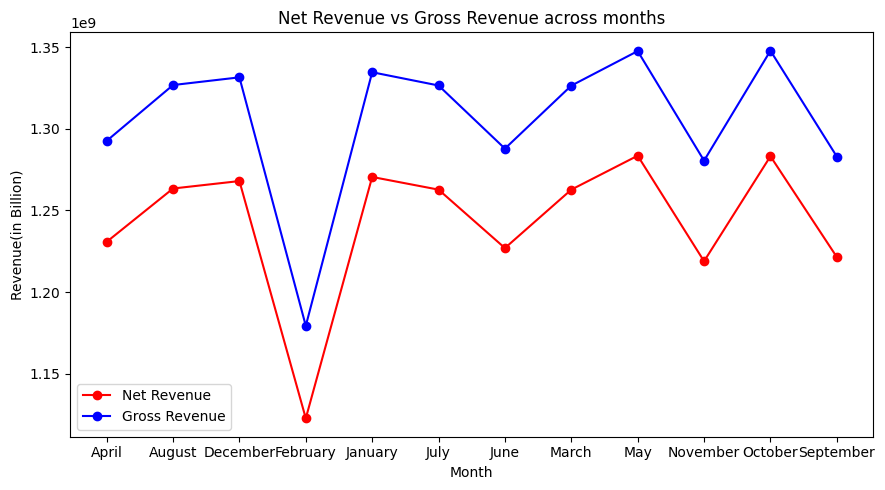

In [53]:
plt.figure(figsize=(9,5))

plt.plot(net_revenue_month.index,net_revenue_month.values, color='red',marker='o',label='Net Revenue')
plt.plot(total_gross_revenue.index,total_gross_revenue.values, color='blue',marker='o',label='Gross Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue(in Billion)')
plt.title('Net Revenue vs Gross Revenue across months')
plt.legend()

plt.tight_layout()
plt.savefig('Net_Revenue_vs_Gross_Revenue.png')
plt.show()

5. 3-panel vertical dashboard - subplot(3,1,n).

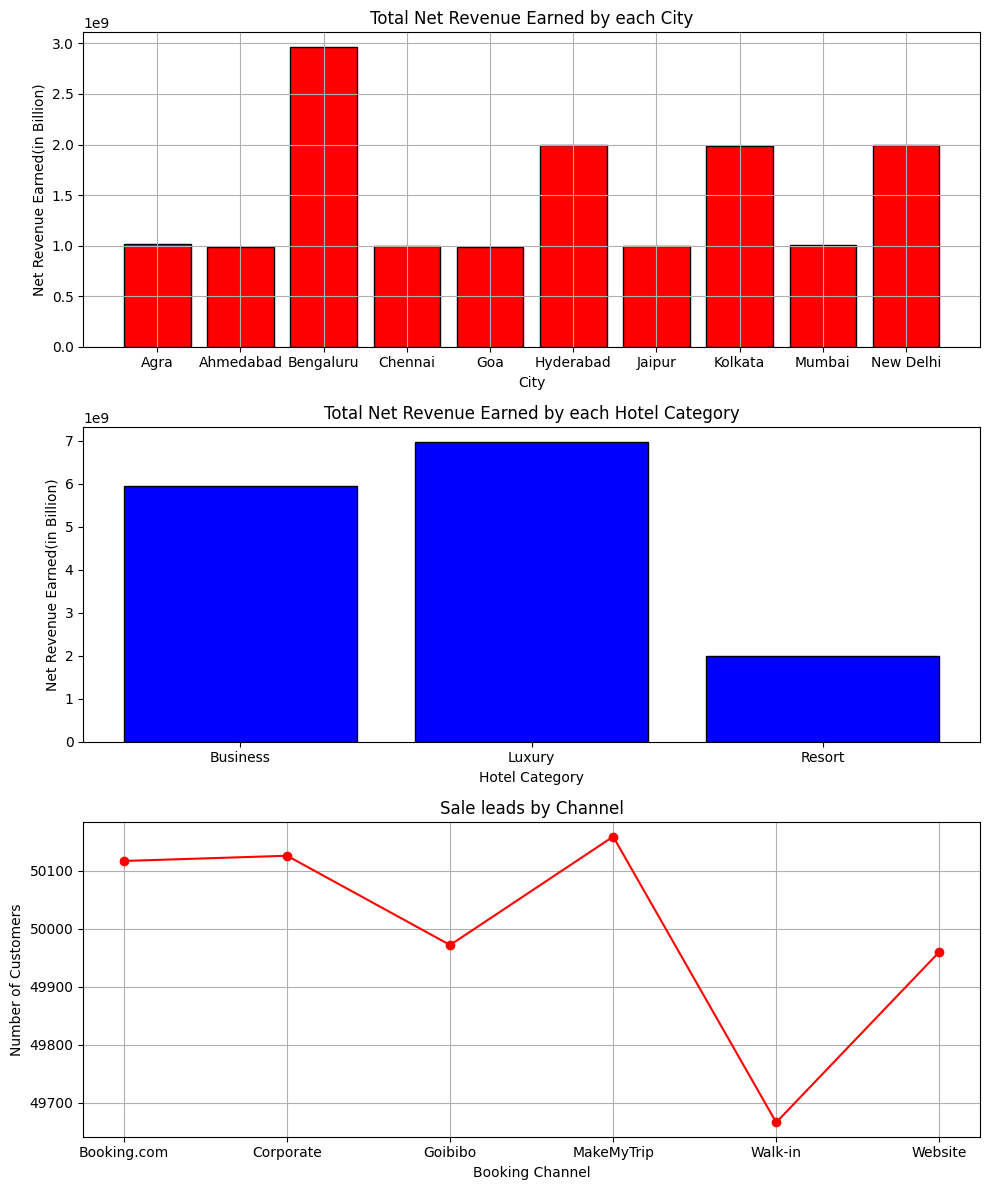

In [54]:
plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1)
revenue_by_city = df_itc.groupby('City')['Net_Revenue'].sum()
plt.bar(revenue_by_city.index,revenue_by_city.values,color='red',edgecolor='black')
plt.xlabel('City')
plt.ylabel('Net Revenue Earned(in Billion)')
plt.grid(True)
plt.title('Total Net Revenue Earned by each City')

plt.subplot(3, 1, 2)
plt.bar(total_net_revenue.index,total_net_revenue.values,color='blue',edgecolor='black')
plt.xlabel('Hotel Category')
plt.ylabel('Net Revenue Earned(in Billion)')
plt.title('Total Net Revenue Earned by each Hotel Category')

plt.subplot(3, 1, 3)
advertisement = df_itc.groupby('Booking_Channel')['Net_Revenue'].count()
plt.plot(advertisement.index,advertisement.values,color='red',marker='o')
plt.xlabel('Booking Channel')
plt.ylabel('Number of Customers')
plt.title('Sale leads by Channel')
plt.grid(True)

plt.tight_layout()
plt.savefig('Dashboard_Vertical.png')
plt.show()



6. 3-panel horizontal dashboard - subplot(1,3,n).

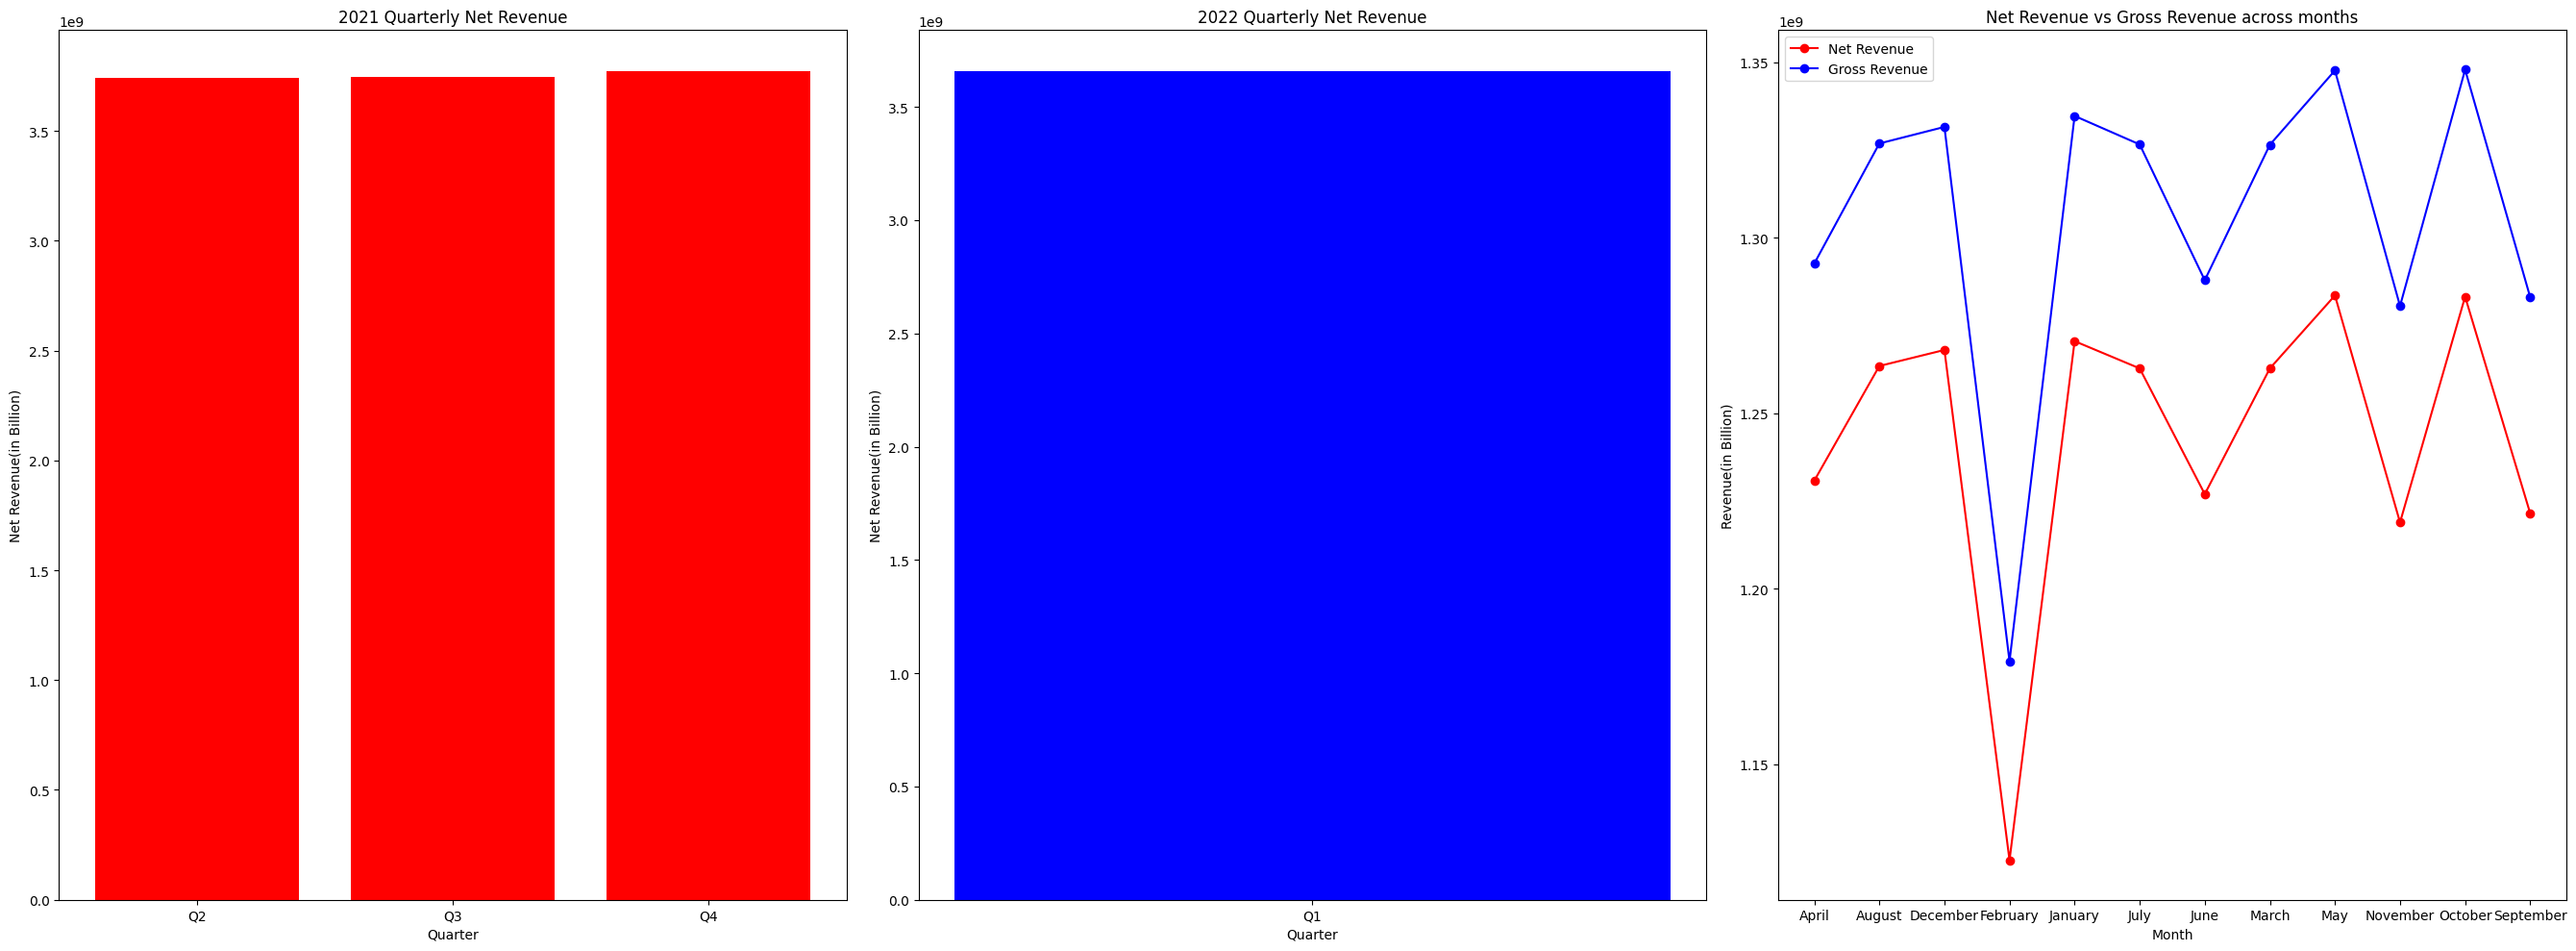

In [55]:
plt.figure(figsize=(27, 10))

x = df_itc[df_itc['Year'] == 2021].groupby('Quarter')['Net_Revenue'].sum()
y = df_itc[df_itc['Year'] == 2022].groupby('Quarter')['Net_Revenue'].sum()

plt.subplot(1,3,1)
plt.bar(x.index,x.values, color='red')
plt.xlabel('Quarter')
plt.ylabel('Net Revenue(in Billion)')
plt.title('2021 Quarterly Net Revenue')

plt.subplot(1,3,2)
plt.bar(y.index,y.values, color='blue')
plt.xlabel('Quarter')
plt.ylabel('Net Revenue(in Billion)')
plt.title('2022 Quarterly Net Revenue')

plt.subplot(1,3,3)
plt.plot(net_revenue_month.index,net_revenue_month.values, color='red',marker='o',label='Net Revenue')
plt.plot(total_gross_revenue.index,total_gross_revenue.values, color='blue',marker='o',label='Gross Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue(in Billion)')
plt.title('Net Revenue vs Gross Revenue across months')
plt.legend()

plt.tight_layout()
plt.savefig('Dashboard_Horizontal.png')
plt.show()


7. 2021 vs 2022 Quarterly Net Revenue - side by side subplots.

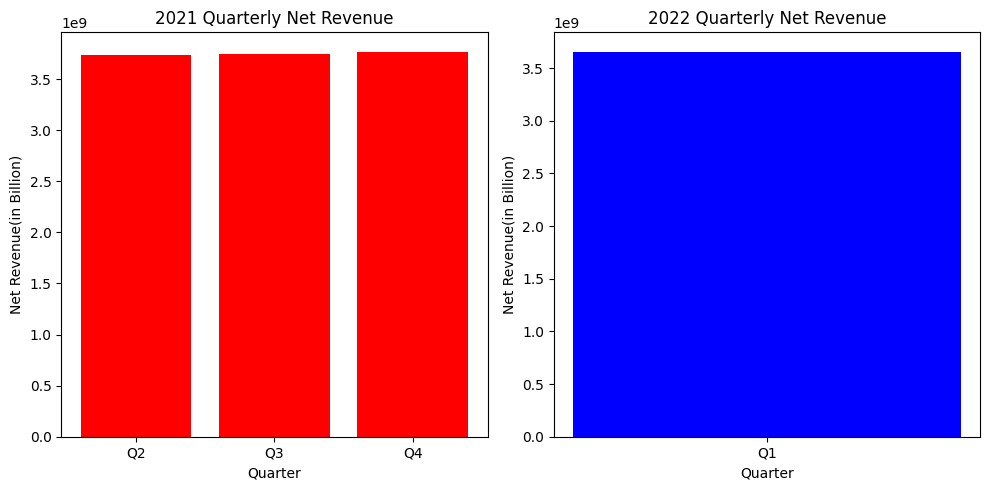

In [56]:
x = df_itc[df_itc['Year'] == 2021].groupby('Quarter')['Net_Revenue'].sum()
y = df_itc[df_itc['Year'] == 2022].groupby('Quarter')['Net_Revenue'].sum()

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.bar(x.index,x.values, color='red')
plt.xlabel('Quarter')
plt.ylabel('Net Revenue(in Billion)')
plt.title('2021 Quarterly Net Revenue')

plt.subplot(1,2,2)
plt.bar(y.index,y.values, color='blue')
plt.xlabel('Quarter')
plt.ylabel('Net Revenue(in Billion)')
plt.title('2022 Quarterly Net Revenue')

plt.tight_layout()
plt.savefig('2021_vs_2022_Quarterly_Net_Revenue.png')
plt.show()

# **Miscellanous**

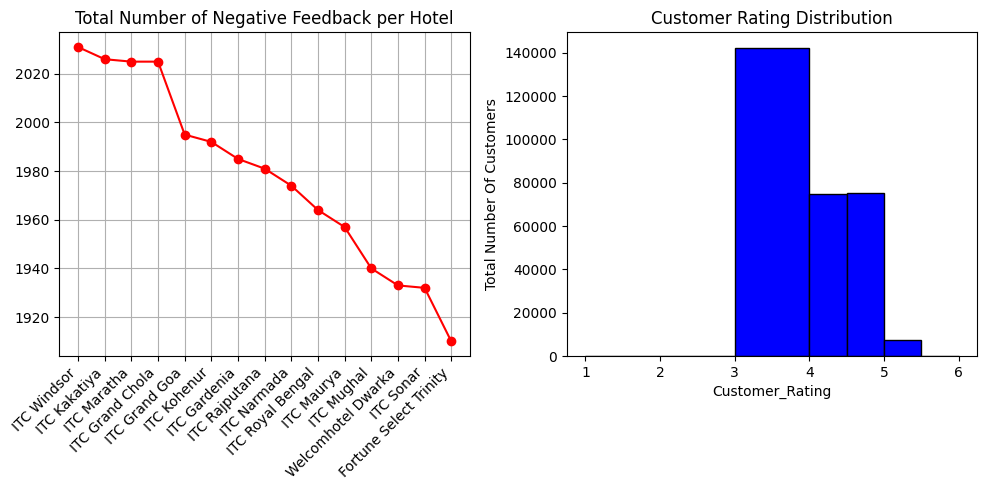

In [80]:
neg_hotel = neg_feedback.groupby('Hotel_Name')['Booking_ID'].count().sort_values(ascending=False)
neg_hotel


plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.plot(neg_hotel.index,neg_hotel.values,color='red',marker='o')


plt.title('Total Number of Negative Feedback per Hotel')
plt.grid(True)

plt.xticks(rotation=45,ha='right')

plt.subplot(1,2,2)
custom_bin = [1,2,3,4,4.5,5.0,5.5,6]
plt.hist(df_itc['Customer_Rating'],custom_bin,color='blue', edgecolor='black')
plt.xlabel('Customer_Rating')
plt.ylabel('Total Number Of Customers')
plt.title('Customer Rating Distribution')

plt.tight_layout()
plt.savefig('Negative_Feedback_and_Customer_Rating_Distribution.png')
plt.show()


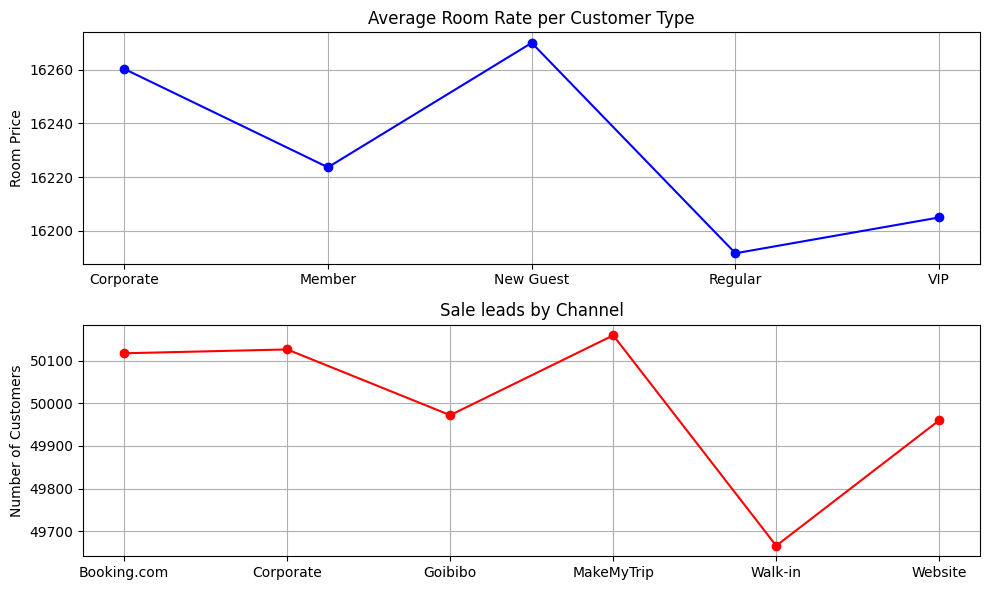

In [114]:
room_rate_cust = df_itc.groupby('Customer_Type')['Room_Rate'].mean()

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(room_rate_cust.index,room_rate_cust.values,color='blue',marker='o')
plt.ylabel('Room Price')
plt.title('Average Room Rate per Customer Type')
plt.grid(True)

plt.subplot(2,1,2)
advertisement = df_itc.groupby('Booking_Channel')['Net_Revenue'].count()
plt.plot(advertisement.index,advertisement.values,color='red',marker='o')

plt.ylabel('Number of Customers')
plt.title('Sale leads by Channel')
plt.grid(True)

plt.tight_layout()
plt.savefig('Dashboard 2.png')
plt.show()